In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [82]:
df = pd.read_csv('/Users/tatabas/Desktop/deled_code_share/test_stochastic/intra-alt-intra/df_delays.csv')

In [83]:
df = df.transpose()
df.columns = df.iloc[0] 
df = df[1:] 
rows_to_drop = [(index) for index in df.index if '--Intra2' in (index)]
df_cleaned = df.drop(rows_to_drop, axis=0)

print(df_cleaned.iloc[0:20,:])
dates = pd.date_range(start="2019-05-01", end="2019-05-02", freq='D').strftime('%Y-%m-%d')


marketing_airline_network            AA        AS        B6        DL  \
2019-05-01-Baseline               702.0      32.0      95.0     386.0   
2019-05-01-Counts                  1358       123       206      1184   
2019-05-01-Baseline-avg        0.516937  0.260163  0.461165  0.326014   
2019-05-01-Baseline-Weighted     4746.0     171.5     700.0    2713.0   
2019-05-01-Intra1                 757.0      32.0      96.0     415.0   
2019-05-01-Intra1-avg          0.557437  0.260163  0.466019  0.350507   
2019-05-01-Intra1-Weighted       3699.5     149.0     686.5    2407.0   
2019-05-01-AA                     668.0      32.0     111.0     447.0   
2019-05-01-AA-Weighted           2989.5     145.5     644.0    2231.0   
2019-05-01-AA-avg                0.4919  0.260163  0.538835  0.377534   
2019-05-01_incr-avg           -0.065538       0.0  0.072816  0.027027   
2019-05-01_delay_ledger       -0.065538       0.0  0.072816  0.027027   
2019-05-01-AA-Intra2              671.0      32.0  

In [84]:
for date in dates:
    # Filter rows that match the specific date and end with "Baseline"
    baseline_row = df_cleaned.filter(like=f'{date}-Intra1-Weighted', axis=0).reset_index(drop=True)
    print(baseline_row)
    if  0 in baseline_row:
        print('zero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero found')
    
    # Filter rows that match the specific date and end with "Intra2"

marketing_airline_network      AA     AS     B6      DL     F9     NK      UA  \
0                          3699.5  149.0  686.5  2407.0  190.0  276.5  2052.5   

marketing_airline_network     WN  
0                          834.5  
marketing_airline_network      AA     AS     B6      DL     F9     NK      UA  \
0                          3361.5  293.0  485.0  2317.5  196.0  408.0  3155.0   

marketing_airline_network     WN  
0                          720.5  


In [85]:
percentage_changes = []
abs_changes = []

for date in dates:
    # Filter rows that match the specific date and end with "Baseline"
    baseline_row = df_cleaned.filter(like=f'{date}-Intra1-Weighted', axis=0).reset_index(drop=True)
    if  0 in baseline_row:
        print('zero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero foundzero found')
    
    # Filter rows that match the specific date and end with "Intra2"
    
    intra2_row = df_cleaned.filter(regex=f'{date}-..-Intra2-Weighted', axis=0).reset_index(drop=True)
    
    # Ensure you have found the correct "Intra2" row for the specific date
    if not intra2_row.empty:
        
        
        # Calculate percentage change
        abs_change = (intra2_row - baseline_row) 
        percentage_change = (intra2_row - baseline_row) / (baseline_row+0.0001) * 100
        percentage_changes.append(percentage_change.values.flatten())
        abs_changes.append(abs_change.values.flatten())
        # Print results
        print(f"delay cost change from Baseline to Intra2 for {date}:")
        print(percentage_change, abs_change)
 

    else:
        print(f"No Intra2 row found for {date}")
percentage_changes = pd.DataFrame(percentage_changes, index = dates, columns = df_cleaned.columns)
abs_changes = pd.DataFrame(abs_changes, index = dates, columns = df_cleaned.columns)
percentage_changes
abs_changes

delay cost change from Baseline to Intra2 for 2019-05-01:
marketing_airline_network        AA        AS        B6        DL        F9  \
0                         -19.71888 -6.711405 -6.190822 -6.439551  0.526316   

marketing_airline_network        NK        UA        WN  
0                         -6.690775 -2.874543 -6.411024   marketing_airline_network     AA    AS    B6     DL   F9    NK    UA    WN
0                         -729.5 -10.0 -42.5 -155.0  1.0 -18.5 -59.0 -53.5
delay cost change from Baseline to Intra2 for 2019-05-02:
marketing_airline_network        AA        AS         B6        DL        F9  \
0                         -3.614458 -6.996585 -66.288646 -6.645091 -0.765306   

marketing_airline_network        NK        UA        WN  
0                         -6.127449 -2.868463 -3.192227   marketing_airline_network     AA    AS     B6     DL   F9    NK    UA    WN
0                         -121.5 -20.5 -321.5 -154.0 -1.5 -25.0 -90.5 -23.0


marketing_airline_network,AA,AS,B6,DL,F9,NK,UA,WN
2019-05-01,-729.5,-10.0,-42.5,-155.0,1.0,-18.5,-59.0,-53.5
2019-05-02,-121.5,-20.5,-321.5,-154.0,-1.5,-25.0,-90.5,-23.0


In [86]:
df_cleaned.filter(regex=f'{"2019-05-01"}-..-avg', axis=0)

marketing_airline_network,AA,AS,B6,DL,F9,NK,UA,WN
2019-05-01-AA-avg,0.4919,0.260163,0.538835,0.377534,0.352273,0.373134,0.443701,0.245113


In [87]:
color_map = {
    'AA': 'gray',      # American
    'UA': 'lightblue', # United
    'DL': 'red',       # Delta
    'WN': 'orange',    # Southwest
    'B6': 'green',     # JetBlue
    'AS': 'blue',      # Alaska
    'NK': 'yellow',    # Spirit
    'F9': 'limegreen'  # Frontier
}


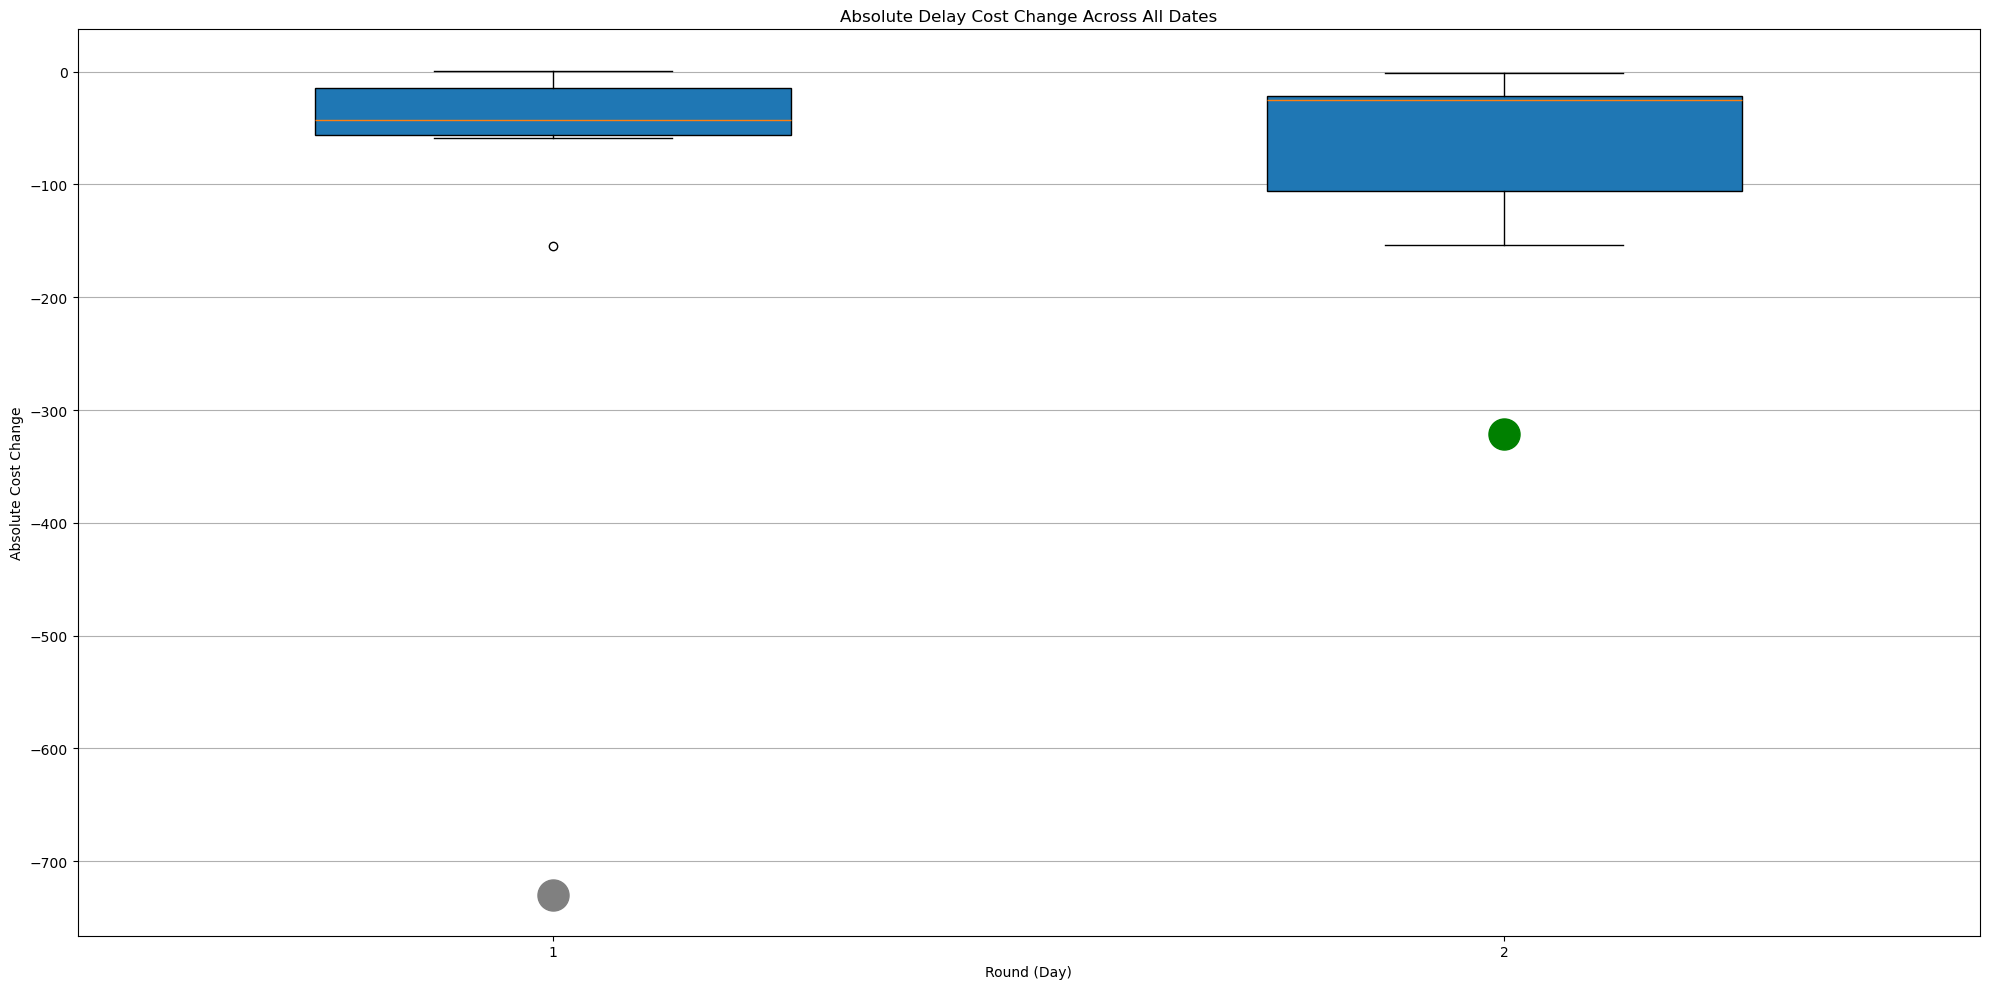

In [88]:
plt.figure(figsize=(20, 10))

# Loop over each date and add the boxplot to the same figure
for i, date in enumerate(dates, start=1):
    baseline_row = df_cleaned.filter(regex=f'{date}-..-avg', axis=0)
    
    if not baseline_row.empty:
        coordinator = baseline_row.index[0][len(date) + 1:len(date) + 3]  # Get the two characters after the date and hyphen
        data_to_plot = abs_changes.loc[date].copy()
        
        coord_data = data_to_plot[coordinator]
    
        data_to_plot.drop(coordinator, inplace=True)

        # Plot the data for this date at a specific position
        
        plt.scatter(i, coord_data, color = color_map[coordinator], s= 500,zorder=4 )
        plt.boxplot(data_to_plot, positions=[i], widths=0.5,patch_artist=True,zorder=3)
# Set title, labels, and format x-ticks
plt.title('Absolute Delay Cost Change Across All Dates')
plt.xlabel('Round (Day)')
plt.ylabel('Absolute Cost Change')
#plt.xticks(range(1, len(dates) + 1), [str(date) for date in dates], rotation=45)
plt.grid(axis='y')

# Show the combined plot
plt.tight_layout()
plt.show()

    

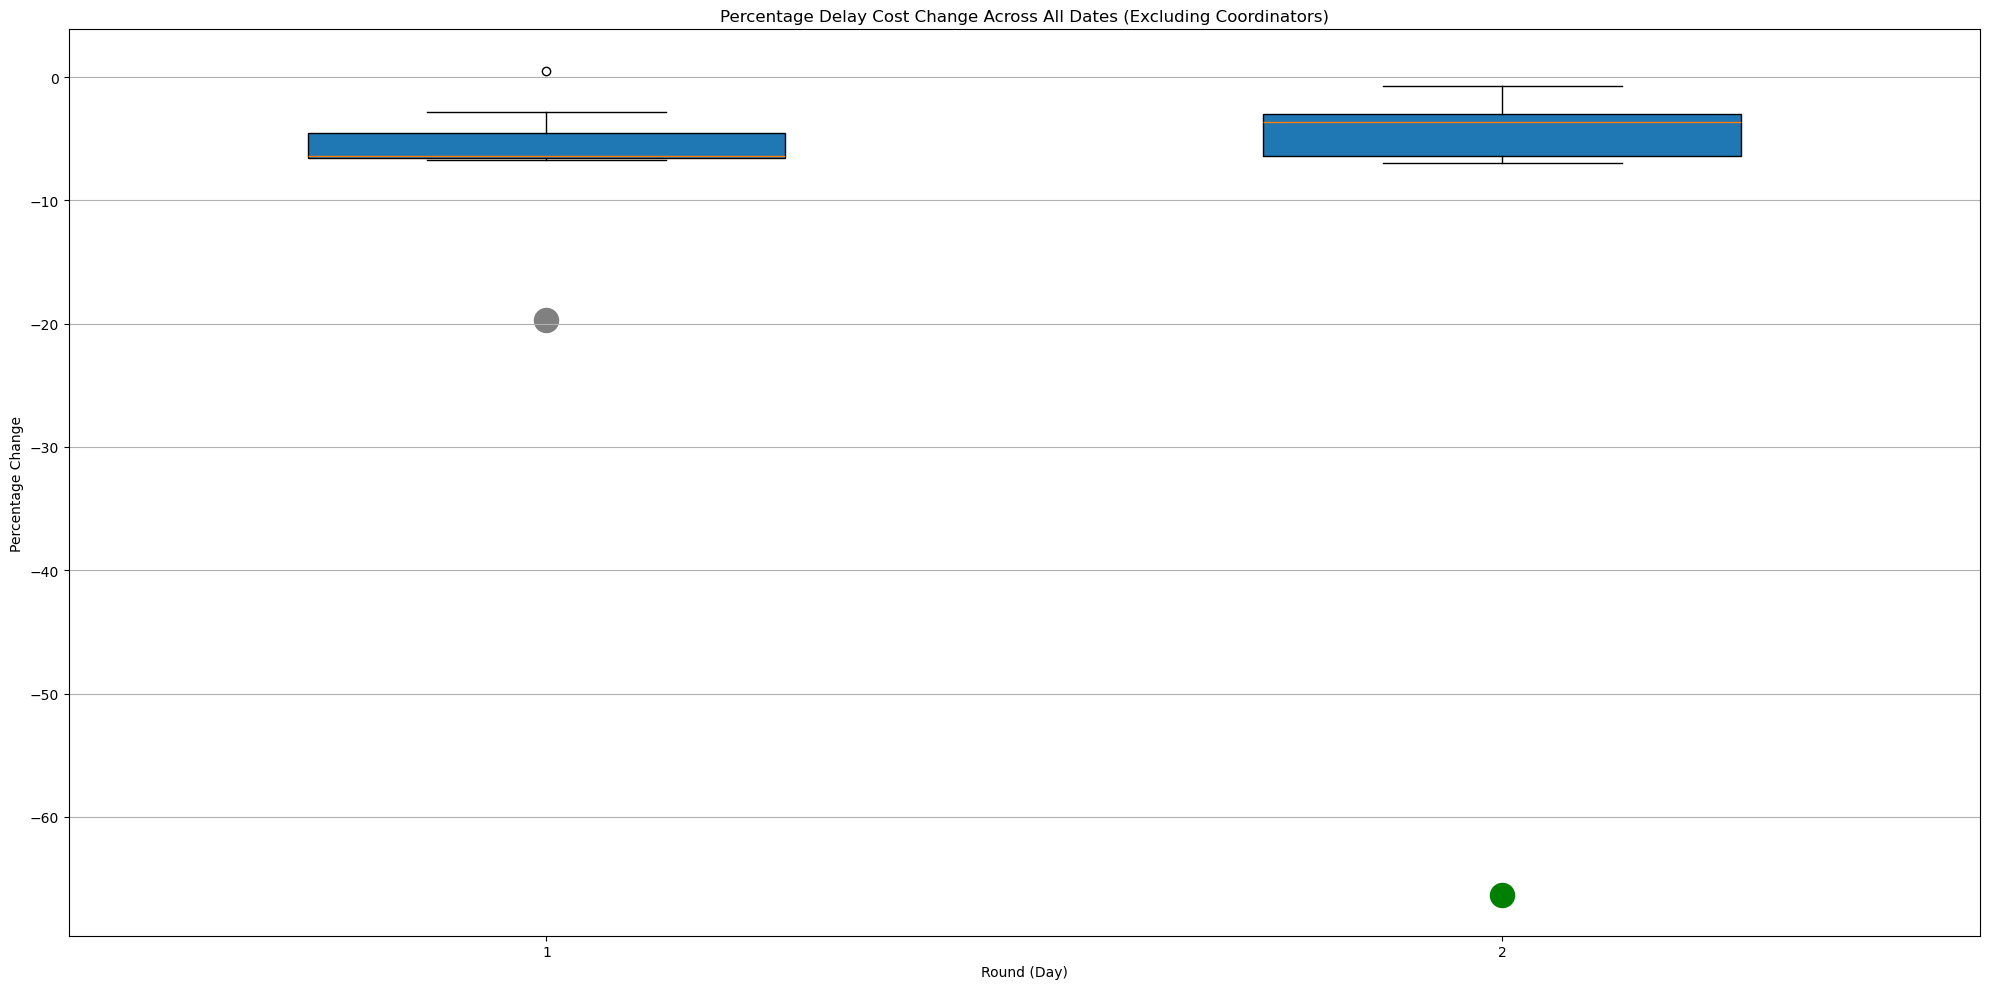

In [89]:
plt.figure(figsize=(20, 10))

# Loop over each date and add the boxplot to the same figure
for i, date in enumerate(dates, start=1):
    baseline_row = df_cleaned.filter(regex=f'{date}-..-avg', axis=0)
    
    if not baseline_row.empty:
        coordinator = baseline_row.index[0][len(date) + 1:len(date) + 3]  # Get the two characters after the date and hyphen
        data_to_plot = percentage_changes.loc[date].copy()
        
        coord_data = data_to_plot[coordinator]
    
        data_to_plot.drop(coordinator, inplace=True)

        # Plot the data for this date at a specific position
        plt.boxplot(data_to_plot, positions=[i], widths=0.5,patch_artist=True)
        plt.scatter(i, coord_data, color = color_map[coordinator], s= 300 )
# Set title, labels, and format x-ticks
plt.title('Percentage Delay Cost Change Across All Dates (Excluding Coordinators)')
plt.xlabel('Round (Day)')
plt.ylabel('Percentage Change')
#plt.xticks(range(1, len(dates) + 1), [str(date) for date in dates], rotation=45)
plt.grid(axis='y')

# Show the combined plot
plt.tight_layout()
plt.show()

    